# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reading and Exploring Dataset Quickly

## Reading Data

In [2]:
df = pd.read_csv("crop_yield.csv").sample(50000)

## Quick Exploring the Data

In [3]:
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
993392,South,Loam,Barley,888.627593,39.254138,False,True,Rainy,136,5.656303
643247,North,Sandy,Maize,781.034886,21.314453,True,True,Rainy,63,5.955529
931513,South,Clay,Wheat,200.427751,21.714764,True,False,Cloudy,130,2.629516
667858,South,Peaty,Barley,868.886009,32.866847,False,False,Sunny,112,6.145907
530818,East,Peaty,Cotton,533.149108,19.866501,False,False,Cloudy,61,2.932254


In [4]:
df.size

500000

In [5]:
df.shape

(50000, 10)

In [6]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,552.271187,27.491561,104.611140,4.664163
std,259.773716,7.214799,25.907271,1.691786
min,100.021326,15.000368,60.000000,-1.147613
25%,327.540613,21.252326,82.000000,3.443170
50%,553.389509,27.540915,105.000000,4.678665
75%,777.208530,33.710271,127.000000,5.882758
max,999.986494,39.999672,149.000000,9.744646


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 993392 to 956496
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Region                  50000 non-null  object 
 1   Soil_Type               50000 non-null  object 
 2   Crop                    50000 non-null  object 
 3   Rainfall_mm             50000 non-null  float64
 4   Temperature_Celsius     50000 non-null  float64
 5   Fertilizer_Used         50000 non-null  bool   
 6   Irrigation_Used         50000 non-null  bool   
 7   Weather_Condition       50000 non-null  object 
 8   Days_to_Harvest         50000 non-null  int64  
 9   Yield_tons_per_hectare  50000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 3.5+ MB


# Data Cleaning

## Checking for data types

In [8]:
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
993392,South,Loam,Barley,888.627593,39.254138,False,True,Rainy,136,5.656303
643247,North,Sandy,Maize,781.034886,21.314453,True,True,Rainy,63,5.955529
931513,South,Clay,Wheat,200.427751,21.714764,True,False,Cloudy,130,2.629516
667858,South,Peaty,Barley,868.886009,32.866847,False,False,Sunny,112,6.145907
530818,East,Peaty,Cotton,533.149108,19.866501,False,False,Cloudy,61,2.932254


In [9]:
df.dtypes

Region                     object
Soil_Type                  object
Crop                       object
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition          object
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

The data types of all columns are correct.

## Data Issues

In [10]:
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
993392,South,Loam,Barley,888.627593,39.254138,False,True,Rainy,136,5.656303
643247,North,Sandy,Maize,781.034886,21.314453,True,True,Rainy,63,5.955529
931513,South,Clay,Wheat,200.427751,21.714764,True,False,Cloudy,130,2.629516
667858,South,Peaty,Barley,868.886009,32.866847,False,False,Sunny,112,6.145907
530818,East,Peaty,Cotton,533.149108,19.866501,False,False,Cloudy,61,2.932254


### Missing Value

In [11]:
df.isna().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

None of the columns contain missing values.

### Incosistent Text and Typos

In [12]:
df["Region"].value_counts()

Region
West     12574
East     12507
North    12479
South    12440
Name: count, dtype: int64

In [13]:
df["Soil_Type"].value_counts()

Soil_Type
Sandy     8448
Peaty     8415
Loam      8337
Chalky    8321
Silt      8277
Clay      8202
Name: count, dtype: int64

In [14]:
df["Crop"].value_counts()

Crop
Maize      8498
Rice       8397
Wheat      8343
Barley     8321
Soybean    8260
Cotton     8181
Name: count, dtype: int64

In [15]:
df["Weather_Condition"].value_counts()

Weather_Condition
Sunny     16726
Rainy     16718
Cloudy    16556
Name: count, dtype: int64

There are no spelling errors in the categorical columns.

In [16]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,552.271187,27.491561,104.611140,4.664163
std,259.773716,7.214799,25.907271,1.691786
min,100.021326,15.000368,60.000000,-1.147613
25%,327.540613,21.252326,82.000000,3.443170
50%,553.389509,27.540915,105.000000,4.678665
75%,777.208530,33.710271,127.000000,5.882758
max,999.986494,39.999672,149.000000,9.744646


No inconsistencies were found in the numerical columns.

### Duplicate Data

In [17]:
df.duplicated().sum()

np.int64(0)

No duplicate data.

### Outliers

In [18]:
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
993392,South,Loam,Barley,888.627593,39.254138,False,True,Rainy,136,5.656303
643247,North,Sandy,Maize,781.034886,21.314453,True,True,Rainy,63,5.955529
931513,South,Clay,Wheat,200.427751,21.714764,True,False,Cloudy,130,2.629516
667858,South,Peaty,Barley,868.886009,32.866847,False,False,Sunny,112,6.145907
530818,East,Peaty,Cotton,533.149108,19.866501,False,False,Cloudy,61,2.932254


array([[<Axes: title={'center': 'Rainfall_mm'}>,
        <Axes: title={'center': 'Temperature_Celsius'}>],
       [<Axes: title={'center': 'Days_to_Harvest'}>,
        <Axes: title={'center': 'Yield_tons_per_hectare'}>]], dtype=object)

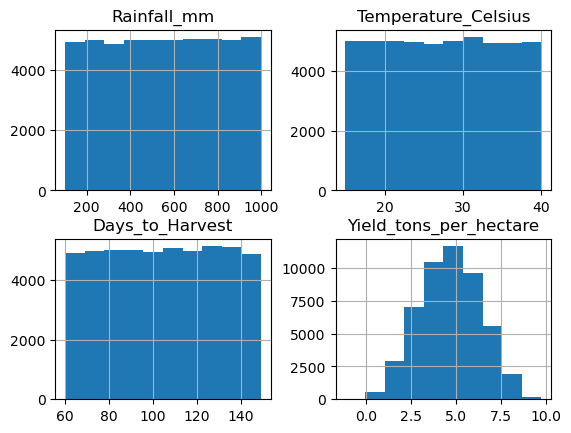

In [19]:
df.hist()

<Axes: ylabel='Count'>

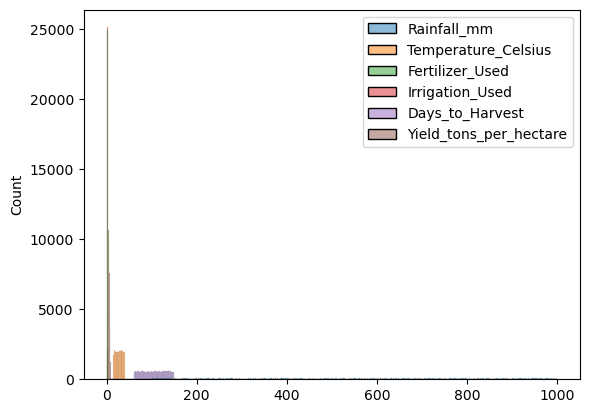

In [20]:
sns.histplot(df, binwidth=1)

<Axes: xlabel='Rainfall_mm'>

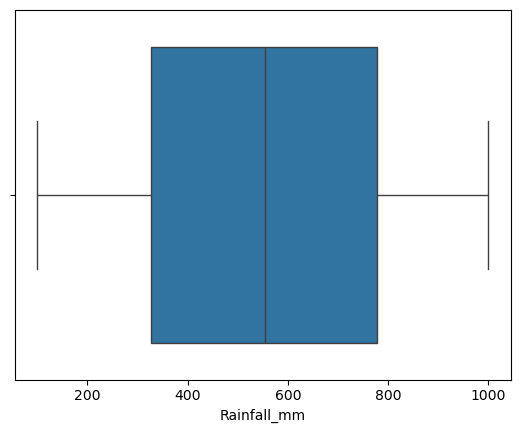

In [21]:
sns.boxplot(x=df["Rainfall_mm"])

<Axes: xlabel='Temperature_Celsius'>

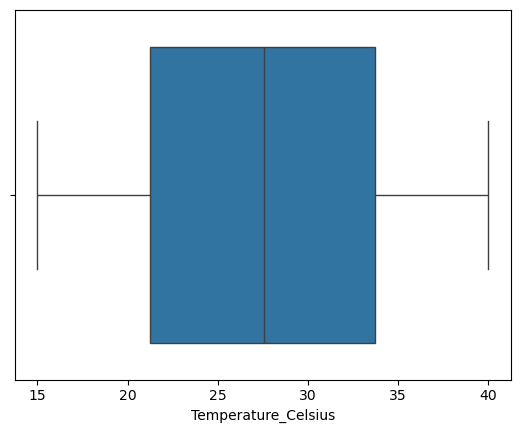

In [22]:
sns.boxplot(x=df["Temperature_Celsius"])

<Axes: xlabel='Days_to_Harvest'>

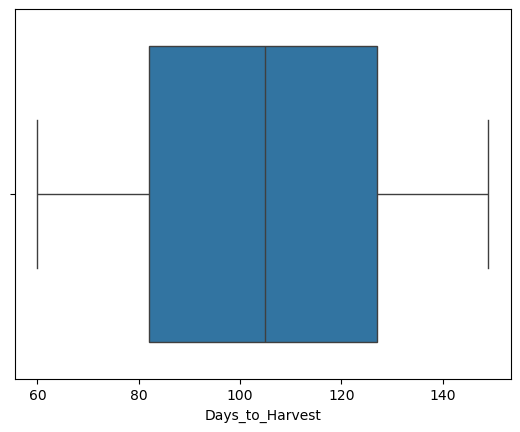

In [23]:
sns.boxplot(x=df["Days_to_Harvest"])

<Axes: ylabel='Yield_tons_per_hectare'>

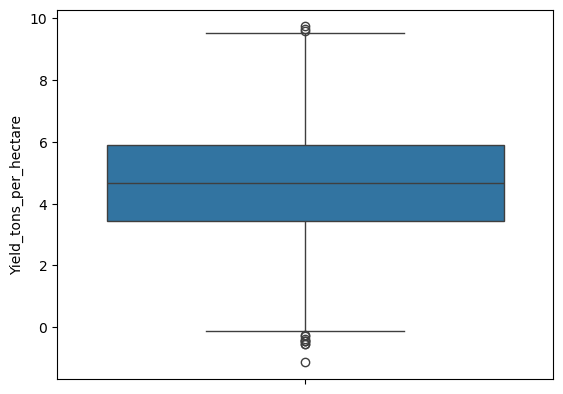

In [24]:
sns.boxplot(df["Yield_tons_per_hectare"])

In [25]:
q25, q50, q75 = np.percentile(df["Yield_tons_per_hectare"], [25, 50, 75])
iqr = q75 - q25
lower = q25 - 1.5*iqr
upper = q75 + 1.5*iqr
print(lower, q25, q50, q75, upper)

-0.21621214447976778 3.443170113885588 4.678664722895602 5.8827582861291585 9.542140544494515


In [26]:
df = df[(df["Yield_tons_per_hectare"]>0) & (df["Yield_tons_per_hectare"]<9.527265554448869)]

<Axes: ylabel='Yield_tons_per_hectare'>

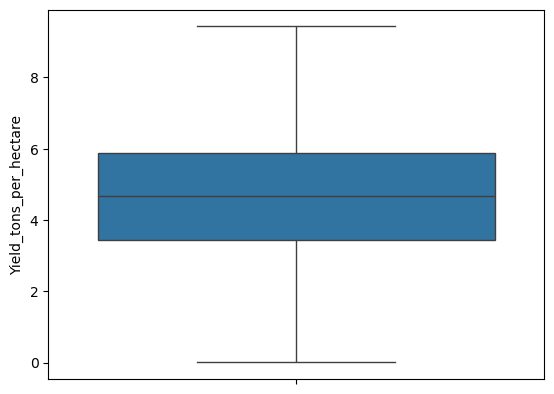

In [27]:
sns.boxplot(df["Yield_tons_per_hectare"])

### Changing Columns Labels

In [28]:
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
993392,South,Loam,Barley,888.627593,39.254138,False,True,Rainy,136,5.656303
643247,North,Sandy,Maize,781.034886,21.314453,True,True,Rainy,63,5.955529
931513,South,Clay,Wheat,200.427751,21.714764,True,False,Cloudy,130,2.629516
667858,South,Peaty,Barley,868.886009,32.866847,False,False,Sunny,112,6.145907
530818,East,Peaty,Cotton,533.149108,19.866501,False,False,Cloudy,61,2.932254


In [29]:
columns = {
    "Region" :"Region",
    "Soil_Type" : "Soil_Type",
    "Crop" : "Crop",
    "Rainfall_mm" : "Rainfall",
    "Temperature_Celsius" : "Temperature",
    "Fertilizer_Used" : "Fertilizer_Used",
    "Irrigation_Used" : "Irrigation_Used",
    "Weather_Condition" : "Weather",
    "Days_to_Harvest" : "Days_to_Harvest",
    "Yield_tons_per_hectare" : "Yield"
}

df = df.rename(columns=columns)
df.head()

,Region,Soil_Type,Crop,Rainfall,Temperature,Fertilizer_Used,Irrigation_Used,Weather,Days_to_Harvest,Yield
993392,South,Loam,Barley,888.627593,39.254138,False,True,Rainy,136,5.656303
643247,North,Sandy,Maize,781.034886,21.314453,True,True,Rainy,63,5.955529
931513,South,Clay,Wheat,200.427751,21.714764,True,False,Cloudy,130,2.629516
667858,South,Peaty,Barley,868.886009,32.866847,False,False,Sunny,112,6.145907
530818,East,Peaty,Cotton,533.149108,19.866501,False,False,Cloudy,61,2.932254


# Exploratory Data Analysis

In [30]:
df.head()

,Region,Soil_Type,Crop,Rainfall,Temperature,Fertilizer_Used,Irrigation_Used,Weather,Days_to_Harvest,Yield
993392,South,Loam,Barley,888.627593,39.254138,False,True,Rainy,136,5.656303
643247,North,Sandy,Maize,781.034886,21.314453,True,True,Rainy,63,5.955529
931513,South,Clay,Wheat,200.427751,21.714764,True,False,Cloudy,130,2.629516
667858,South,Peaty,Barley,868.886009,32.866847,False,False,Sunny,112,6.145907
530818,East,Peaty,Cotton,533.149108,19.866501,False,False,Cloudy,61,2.932254


<Axes: xlabel='Yield', ylabel='Count'>

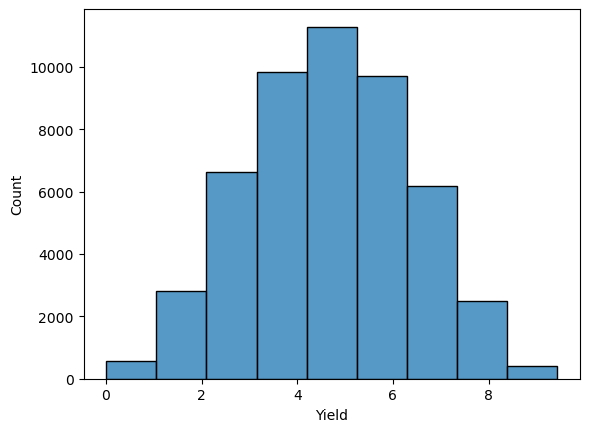

In [31]:
sns.histplot(df["Yield"], binwidth=1)

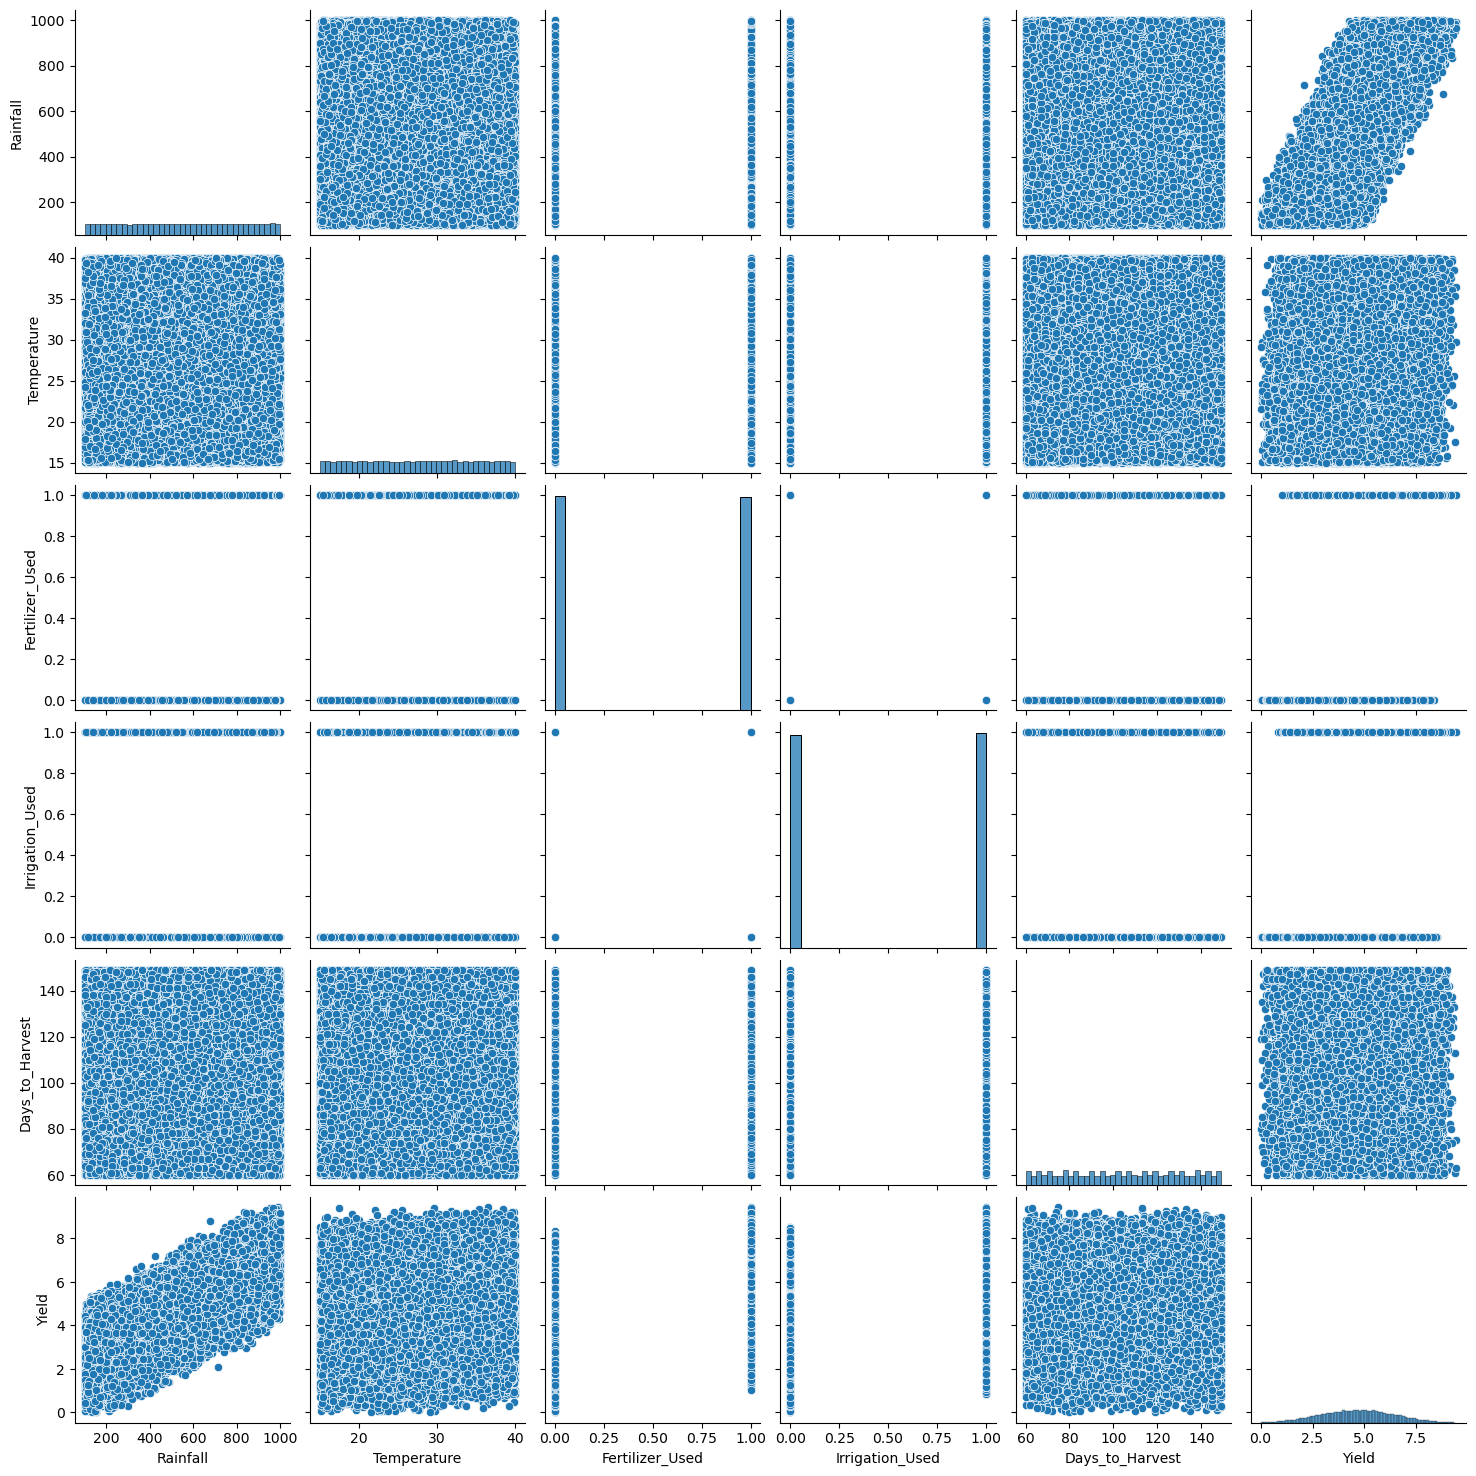

In [32]:
sns.pairplot(df);

In [33]:
df.corr(numeric_only=True)

,Rainfall,Temperature,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield
Rainfall,1.000000,-0.008778,-0.004554,-0.005547,0.000794,0.764551
Temperature,-0.008778,1.000000,0.004080,-0.006406,0.004793,0.079689
Fertilizer_Used,-0.004554,0.004080,1.000000,-0.004136,-0.000800,0.438982
Irrigation_Used,-0.005547,-0.006406,-0.004136,1.000000,-0.000776,0.347233
Days_to_Harvest,0.000794,0.004793,-0.000800,-0.000776,1.000000,-0.000600
Yield,0.764551,0.079689,0.438982,0.347233,-0.000600,1.000000


Rainfall has a very strong correlation with Yield.

Fertilizer_Used has a strong correlation with Yield.

Irrigation_Used is correlated with Yield.

# Saving the Cleaning Dataset

In [35]:
df.to_csv("cleaned_dataset.csv", index=False)